<h1>Содержание<span class="tocSkip"></span></h1>


#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

## Подготовка

Изначально импортируем необходимые библиотеки.

In [1]:
!pip install ydata_profiling

In [2]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, GridSearchCV, cross_val_score)
from catboost import CatBoostRegressor
from catboost import Pool, cv
import ydata_profiling
from sklearn.metrics import (mean_squared_error, make_scorer)
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
import ydata_profiling

В переменной с датасетом преобразуем столбец дат и заидендексируем его.

In [3]:
data = pd.read_csv('/datasets/taxi.csv', parse_dates=[0], index_col=[0])

Отсортируем даты и убедимся в правильности сортировки.

In [4]:
#data = data.set_index('datetime')
#data = data.sort_index()
data.sort_index(inplace=True)
data.index.is_monotonic

True

Кратко взглянем на данные.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [6]:
data.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


Пока что нельзя выделить что-то, можно лишь убедиться, что все в порядке.

Для машинного обучения ресемплируем данные до 1 часа.

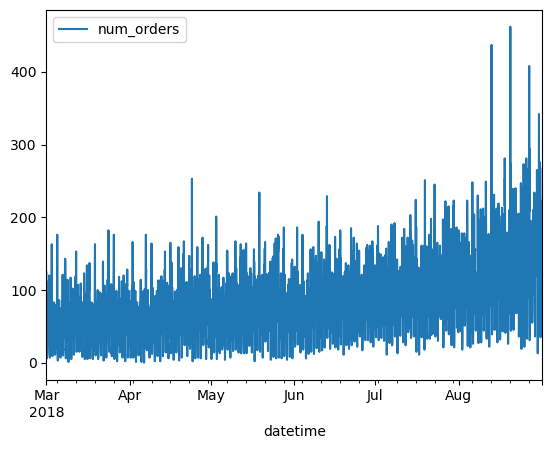

In [7]:
data = data.resample('1H').sum()
data.plot();

Перед обучением проанализируем данные.

## Анализ

In [8]:
#ydata_profiling.ProfileReport(data)

Для анализа ресемплируем данные до 1 дня, чтобы было удобнее.

In [9]:
data_to_rolling = data.resample('1D').sum()

Рассмотрим график со средним скользящим и скользящим стандартным отклонением.

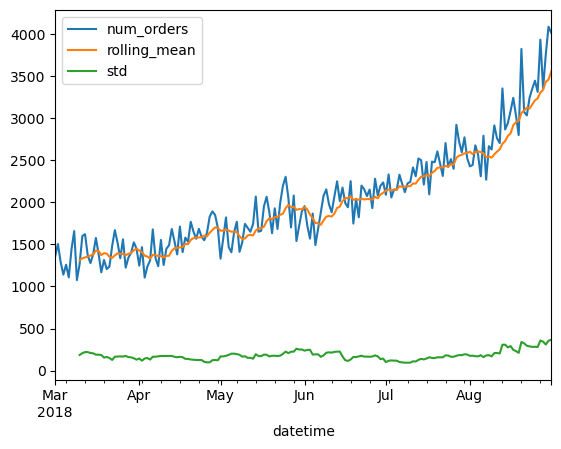

In [10]:
data_to_rolling['rolling_mean'] = data_to_rolling['num_orders'].rolling(10).mean()
data_to_rolling['std'] = data_to_rolling['num_orders'].rolling(10).std()
data_to_rolling.plot();

График восходящий, среднее незначительно отличается, стандартное отклонение в норме (небольшие показатели).

Взглянем на те же, но стационарные показатели.

In [11]:
data_to_rolling_shift = data.resample('1D').sum() - data.resample('1D').sum().shift()

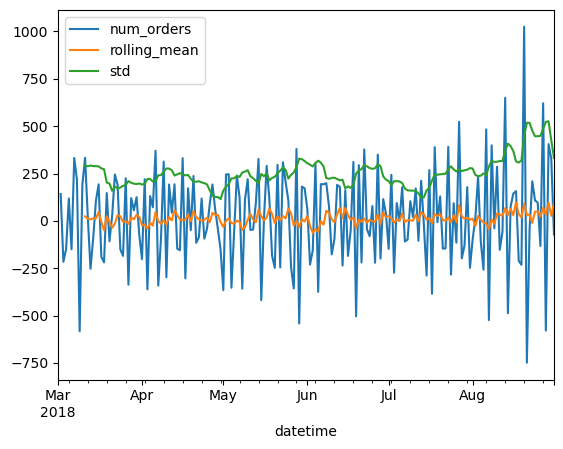

In [12]:
data_to_rolling_shift['rolling_mean'] = data_to_rolling_shift['num_orders'].rolling(10).mean()
data_to_rolling_shift['std'] = data_to_rolling_shift['num_orders'].rolling(10).std()
data_to_rolling_shift.plot();

Оценим тренд, сезонность и остаток.

In [13]:
data_to_trend = data.resample('1D').sum()

In [14]:
decomposed = seasonal_decompose(data_to_trend)

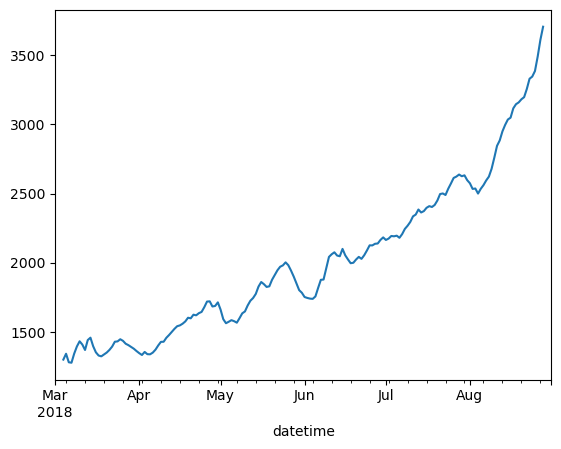

In [15]:
decomposed.trend.plot(ax=plt.gca());

Тренд восходящий, как и в первом графике.

Рассмотрим сезонность в двухнедельный период.

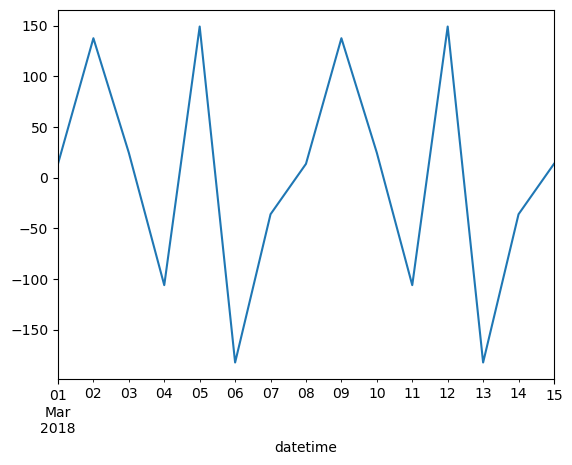

In [16]:
decomposed.seasonal['2018-03-01': '2018-03-15'].plot(ax=plt.gca()); 

Не совсем ясно, с чем могут быть связаны подобные частые колебания.

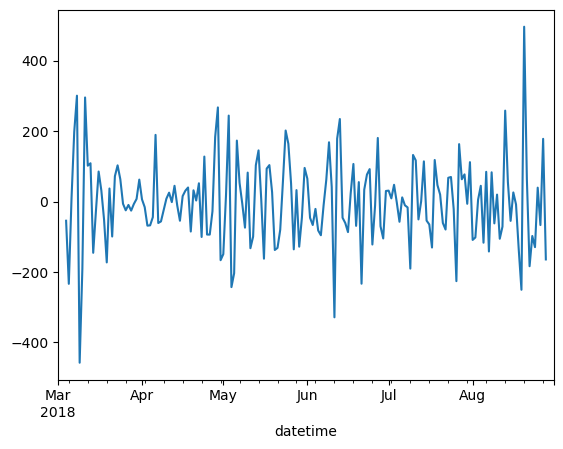

In [17]:
decomposed.resid.plot(ax=plt.gca());

Остатки необъяснимы.

## Обучение

### Подготовка признаков и выборок

Для предсказания нам необходимы признаки. Создадим функцию для их формирования. Выделим календарные признаки, "отстающее значение" и скользящее среднее.

In [18]:
def make_features(data, max_lag, rolling_mean_size):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    data['rolling_mean'] = data['num_orders'].shift().rolling(rolling_mean_size).mean()

In [19]:
make_features(data, 80, 10)

Взглянем на данные.

In [20]:
data.head(10)

,num_orders,year,month,day,dayofweek,lag_1,lag_2,lag_3,lag_4,lag_5,...,lag_72,lag_73,lag_74,lag_75,lag_76,lag_77,lag_78,lag_79,lag_80,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-01 00:00:00,124,2018,3,1,3,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,2018,3,1,3,124.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,2018,3,1,3,85.0,124.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 03:00:00,66,2018,3,1,3,71.0,85.0,124.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 04:00:00,43,2018,3,1,3,66.0,71.0,85.0,124.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 05:00:00,6,2018,3,1,3,43.0,66.0,71.0,85.0,124.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 06:00:00,12,2018,3,1,3,6.0,43.0,66.0,71.0,85.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 07:00:00,15,2018,3,1,3,12.0,6.0,43.0,66.0,71.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 08:00:00,34,2018,3,1,3,15.0,12.0,6.0,43.0,66.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Значительно увеличилось количество пропусков в первых строках. Избавимся от них.

In [21]:
data.isna().sum()

num_orders       0
year             0
month            0
day              0
dayofweek        0
                ..
lag_77          77
lag_78          78
lag_79          79
lag_80          80
rolling_mean    10
Length: 86, dtype: int64

In [22]:
data = data.dropna()

Выделим тренировочную и тестовую выборку с размерностью 9:1. Проверим границы выборок.

In [23]:
train, test = train_test_split(data, shuffle=False, test_size=0.1)
train = train.dropna()

print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

2018-03-04 08:00:00 2018-08-13 21:00:00
2018-08-13 22:00:00 2018-08-31 23:00:00


Выделим признаки.

In [24]:
features_train = train.drop('num_orders', axis=1)
target_train = train['num_orders']

features_test = test.drop('num_orders', axis=1)
target_test = test['num_orders']

### CatBoost

Начнем рассматривать модели. Подберем параметры для кэтбуста.

In [25]:
parameters_cat = {
        'learning_rate': [0.05, 0.1],
        'depth': [6, 8],
        #'l2_leaf_reg': [1, 3, 5, 7, 9],
        
}


model_cat = CatBoostRegressor(loss_function = 'RMSE', random_state = 12345)

In [26]:
%%time

gs_cat = model_cat.grid_search(parameters_cat, features_train, target_train, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 84.1946482	test: 83.6538860	best: 83.6538860 (0)	total: 149ms	remaining: 2m 28s
1:	learn: 80.6330908	test: 80.1190372	best: 80.1190372 (1)	total: 156ms	remaining: 1m 17s
2:	learn: 77.2430635	test: 76.6715607	best: 76.6715607 (2)	total: 162ms	remaining: 53.9s
3:	learn: 73.9930109	test: 73.4126043	best: 73.4126043 (3)	total: 169ms	remaining: 42.1s
4:	learn: 71.0395952	test: 70.4599548	best: 70.4599548 (4)	total: 176ms	remaining: 35.1s
5:	learn: 68.2044689	test: 67.5862134	best: 67.5862134 (5)	total: 183ms	remaining: 30.3s
6:	learn: 65.5355459	test: 64.9260044	best: 64.9260044 (6)	total: 190ms	remaining: 26.9s
7:	learn: 63.0710505	test: 62.4933314	best: 62.4933314 (7)	total: 197ms	remaining: 24.4s
8:	learn: 60.6411084	test: 60.0568667	best: 60.0568667 (8)	total: 204ms	remaining: 22.4s
9:	learn: 58.3447154	test: 57.7062675	best: 57.7062675 (9)	total: 211ms	remaining: 20.8s
10:	learn: 56.1881737	test: 55.5206304	best: 55.5206304 (10)	total: 217ms	remaining: 19.5s
11:	learn: 54.173

95:	learn: 21.3080501	test: 22.7355678	best: 22.7355678 (95)	total: 759ms	remaining: 7.15s
96:	learn: 21.2678701	test: 22.7147057	best: 22.7147057 (96)	total: 767ms	remaining: 7.14s
97:	learn: 21.2356355	test: 22.7102064	best: 22.7102064 (97)	total: 773ms	remaining: 7.12s
98:	learn: 21.2037738	test: 22.6995953	best: 22.6995953 (98)	total: 780ms	remaining: 7.09s
99:	learn: 21.1736885	test: 22.6929670	best: 22.6929670 (99)	total: 786ms	remaining: 7.07s
100:	learn: 21.1428148	test: 22.6824759	best: 22.6824759 (100)	total: 792ms	remaining: 7.05s
101:	learn: 21.1142125	test: 22.6744166	best: 22.6744166 (101)	total: 799ms	remaining: 7.04s
102:	learn: 21.0755987	test: 22.6672604	best: 22.6672604 (102)	total: 806ms	remaining: 7.02s
103:	learn: 21.0317502	test: 22.6515285	best: 22.6515285 (103)	total: 812ms	remaining: 7s
104:	learn: 21.0065265	test: 22.6407059	best: 22.6407059 (104)	total: 818ms	remaining: 6.97s
105:	learn: 20.9620079	test: 22.6410160	best: 22.6407059 (104)	total: 825ms	remaini

186:	learn: 19.0054849	test: 22.1474070	best: 22.1474070 (186)	total: 1.37s	remaining: 5.96s
187:	learn: 18.9853611	test: 22.1369343	best: 22.1369343 (187)	total: 1.38s	remaining: 5.95s
188:	learn: 18.9586070	test: 22.1484509	best: 22.1369343 (187)	total: 1.38s	remaining: 5.94s
189:	learn: 18.9228034	test: 22.1374864	best: 22.1369343 (187)	total: 1.39s	remaining: 5.93s
190:	learn: 18.9198687	test: 22.1374707	best: 22.1369343 (187)	total: 1.4s	remaining: 5.92s
191:	learn: 18.8981036	test: 22.1185261	best: 22.1185261 (191)	total: 1.4s	remaining: 5.91s
192:	learn: 18.8929806	test: 22.1203064	best: 22.1185261 (191)	total: 1.41s	remaining: 5.89s
193:	learn: 18.8692581	test: 22.1195996	best: 22.1185261 (191)	total: 1.42s	remaining: 5.88s
194:	learn: 18.8373313	test: 22.1006974	best: 22.1006974 (194)	total: 1.42s	remaining: 5.87s
195:	learn: 18.8314127	test: 22.1024180	best: 22.1006974 (194)	total: 1.43s	remaining: 5.86s
196:	learn: 18.7949592	test: 22.0980422	best: 22.0980422 (196)	total: 1.

275:	learn: 17.0036504	test: 21.7212785	best: 21.7193051 (270)	total: 1.99s	remaining: 5.21s
276:	learn: 16.9832850	test: 21.7218822	best: 21.7193051 (270)	total: 2s	remaining: 5.21s
277:	learn: 16.9575163	test: 21.7308353	best: 21.7193051 (270)	total: 2s	remaining: 5.2s
278:	learn: 16.9396331	test: 21.7278107	best: 21.7193051 (270)	total: 2.01s	remaining: 5.19s
279:	learn: 16.9132321	test: 21.7312814	best: 21.7193051 (270)	total: 2.02s	remaining: 5.19s
280:	learn: 16.9055844	test: 21.7314156	best: 21.7193051 (270)	total: 2.02s	remaining: 5.18s
281:	learn: 16.8808948	test: 21.7295664	best: 21.7193051 (270)	total: 2.03s	remaining: 5.17s
282:	learn: 16.8637861	test: 21.7254872	best: 21.7193051 (270)	total: 2.04s	remaining: 5.16s
283:	learn: 16.8478129	test: 21.7191142	best: 21.7191142 (283)	total: 2.04s	remaining: 5.15s
284:	learn: 16.8235629	test: 21.7202785	best: 21.7191142 (283)	total: 2.05s	remaining: 5.14s
285:	learn: 16.8089992	test: 21.7211657	best: 21.7191142 (283)	total: 2.06s	r

...

524:	learn: 12.2996752	test: 22.6281806	best: 22.6120769 (512)	total: 3.2s	remaining: 2.89s
525:	learn: 12.2807520	test: 22.6232587	best: 22.6120769 (512)	total: 3.2s	remaining: 2.89s
526:	learn: 12.2746585	test: 22.6253032	best: 22.6120769 (512)	total: 3.21s	remaining: 2.88s
527:	learn: 12.2648788	test: 22.6278146	best: 22.6120769 (512)	total: 3.21s	remaining: 2.87s
528:	learn: 12.2550865	test: 22.6299284	best: 22.6120769 (512)	total: 3.22s	remaining: 2.87s
529:	learn: 12.2540534	test: 22.6306539	best: 22.6120769 (512)	total: 3.23s	remaining: 2.86s
530:	learn: 12.2359308	test: 22.6267227	best: 22.6120769 (512)	total: 3.23s	remaining: 2.86s
531:	learn: 12.2238435	test: 22.6275774	best: 22.6120769 (512)	total: 3.24s	remaining: 2.85s
532:	learn: 12.2061353	test: 22.6247879	best: 22.6120769 (512)	total: 3.25s	remaining: 2.84s
533:	learn: 12.1868849	test: 22.6289042	best: 22.6120769 (512)	total: 3.25s	remaining: 2.84s
534:	learn: 12.1850323	test: 22.6308300	best: 22.6120769 (512)	total: 3.

626:	learn: 11.1505514	test: 22.5616974	best: 22.5616974 (626)	total: 3.82s	remaining: 2.27s
627:	learn: 11.1348578	test: 22.5563479	best: 22.5563479 (627)	total: 3.83s	remaining: 2.27s
628:	learn: 11.1221488	test: 22.5553315	best: 22.5553315 (628)	total: 3.83s	remaining: 2.26s
629:	learn: 11.1114933	test: 22.5581212	best: 22.5553315 (628)	total: 3.84s	remaining: 2.25s
630:	learn: 11.1075112	test: 22.5587070	best: 22.5553315 (628)	total: 3.85s	remaining: 2.25s
631:	learn: 11.0971826	test: 22.5584379	best: 22.5553315 (628)	total: 3.85s	remaining: 2.24s
632:	learn: 11.0949601	test: 22.5589977	best: 22.5553315 (628)	total: 3.86s	remaining: 2.24s
633:	learn: 11.0926175	test: 22.5606475	best: 22.5553315 (628)	total: 3.86s	remaining: 2.23s
634:	learn: 11.0827196	test: 22.5616077	best: 22.5553315 (628)	total: 3.87s	remaining: 2.22s
635:	learn: 11.0696272	test: 22.5593854	best: 22.5553315 (628)	total: 3.88s	remaining: 2.22s
636:	learn: 11.0570784	test: 22.5623129	best: 22.5553315 (628)	total: 

727:	learn: 10.0801564	test: 22.4919069	best: 22.4874448 (725)	total: 4.43s	remaining: 1.66s
728:	learn: 10.0686013	test: 22.4890947	best: 22.4874448 (725)	total: 4.44s	remaining: 1.65s
729:	learn: 10.0545679	test: 22.4893389	best: 22.4874448 (725)	total: 4.44s	remaining: 1.64s
730:	learn: 10.0527062	test: 22.4909221	best: 22.4874448 (725)	total: 4.45s	remaining: 1.64s
731:	learn: 10.0391161	test: 22.4931814	best: 22.4874448 (725)	total: 4.46s	remaining: 1.63s
732:	learn: 10.0291297	test: 22.4918849	best: 22.4874448 (725)	total: 4.46s	remaining: 1.63s
733:	learn: 10.0216238	test: 22.4889677	best: 22.4874448 (725)	total: 4.47s	remaining: 1.62s
734:	learn: 10.0210272	test: 22.4897022	best: 22.4874448 (725)	total: 4.47s	remaining: 1.61s
735:	learn: 10.0084726	test: 22.4884294	best: 22.4874448 (725)	total: 4.48s	remaining: 1.61s
736:	learn: 9.9925811	test: 22.4888164	best: 22.4874448 (725)	total: 4.49s	remaining: 1.6s
737:	learn: 9.9766295	test: 22.4901218	best: 22.4874448 (725)	total: 4.4

826:	learn: 9.0893368	test: 22.4642531	best: 22.4487906 (805)	total: 5.04s	remaining: 1.05s
827:	learn: 9.0783914	test: 22.4619738	best: 22.4487906 (805)	total: 5.04s	remaining: 1.05s
828:	learn: 9.0686130	test: 22.4612999	best: 22.4487906 (805)	total: 5.05s	remaining: 1.04s
829:	learn: 9.0540166	test: 22.4598554	best: 22.4487906 (805)	total: 5.05s	remaining: 1.03s
830:	learn: 9.0465529	test: 22.4586747	best: 22.4487906 (805)	total: 5.06s	remaining: 1.03s
831:	learn: 9.0347961	test: 22.4606917	best: 22.4487906 (805)	total: 5.07s	remaining: 1.02s
832:	learn: 9.0200015	test: 22.4641007	best: 22.4487906 (805)	total: 5.07s	remaining: 1.02s
833:	learn: 9.0109847	test: 22.4645685	best: 22.4487906 (805)	total: 5.08s	remaining: 1.01s
834:	learn: 9.0103535	test: 22.4651151	best: 22.4487906 (805)	total: 5.08s	remaining: 1s
835:	learn: 8.9962063	test: 22.4676539	best: 22.4487906 (805)	total: 5.09s	remaining: 999ms
836:	learn: 8.9859936	test: 22.4621170	best: 22.4487906 (805)	total: 5.1s	remaining

922:	learn: 8.2382400	test: 22.4380220	best: 22.4380220 (922)	total: 5.65s	remaining: 471ms
923:	learn: 8.2323012	test: 22.4377135	best: 22.4377135 (923)	total: 5.65s	remaining: 465ms
924:	learn: 8.2253651	test: 22.4374810	best: 22.4374810 (924)	total: 5.66s	remaining: 459ms
925:	learn: 8.2129316	test: 22.4368419	best: 22.4368419 (925)	total: 5.67s	remaining: 453ms
926:	learn: 8.2021246	test: 22.4369847	best: 22.4368419 (925)	total: 5.67s	remaining: 447ms
927:	learn: 8.1932837	test: 22.4356241	best: 22.4356241 (927)	total: 5.68s	remaining: 441ms
928:	learn: 8.1791242	test: 22.4355667	best: 22.4355667 (928)	total: 5.68s	remaining: 434ms
929:	learn: 8.1683483	test: 22.4346295	best: 22.4346295 (929)	total: 5.69s	remaining: 428ms
930:	learn: 8.1678348	test: 22.4351158	best: 22.4346295 (929)	total: 5.7s	remaining: 422ms
931:	learn: 8.1552259	test: 22.4327380	best: 22.4327380 (931)	total: 5.7s	remaining: 416ms
932:	learn: 8.1442839	test: 22.4300712	best: 22.4300712 (932)	total: 5.71s	remaini

In [27]:
gs_cat['params']

{'depth': 6, 'learning_rate': 0.05}

Проверим на кросс-валидации.

In [28]:
train_dataset = Pool(features_train, target_train) 

In [29]:
params_cat = {
          "depth": 6,
          "eval_metric": "RMSE",
          "loss_function": "RMSE",
          "learning_rate": 0.05,
          "verbose": 100}

scores = cv(params = params_cat,
            pool = train_dataset,
            fold_count=3,
            shuffle = True,
            plot="True",
            partition_random_seed = 0)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/3]
0:	learn: 84.2994337	test: 83.8292895	best: 83.8292895 (0)	total: 21.2ms	remaining: 21.2s
100:	learn: 20.8553332	test: 22.9255493	best: 22.9252124 (99)	total: 617ms	remaining: 5.49s
200:	learn: 18.5264841	test: 22.2912469	best: 22.2880325 (199)	total: 1.22s	remaining: 4.86s
300:	learn: 15.9586358	test: 21.9386004	best: 21.9383260 (299)	total: 1.92s	remaining: 4.45s
400:	learn: 14.0482003	test: 21.7940583	best: 21.7940583 (400)	total: 2.56s	remaining: 3.83s
500:	learn: 12.6046772	test: 21.7317635	best: 21.7276808 (493)	total: 3.17s	remaining: 3.16s
600:	learn: 11.2888328	test: 21.6886769	best: 21.6844824 (595)	total: 3.79s	remaining: 2.52s
700:	learn: 10.1777108	test: 21.6503849	best: 21.6503849 (700)	total: 4.46s	remaining: 1.9s
800:	learn: 9.1220512	test: 21.6252427	best: 21.6246759 (771)	total: 5.07s	remaining: 1.26s
900:	learn: 8.2216715	test: 21.6089448	best: 21.6089448 (900)	total: 5.66s	remaining: 622ms
999:	learn: 7.4520515	test: 21.6128430	best: 21.605815

In [30]:
scores['test-RMSE-mean']

0      84.147404
1      80.730992
2      77.403773
3      74.250164
4      71.237883
         ...    
995    21.713074
996    21.712735
997    21.712906
998    21.714628
999    21.714689
Name: test-RMSE-mean, Length: 1000, dtype: float64

In [31]:
scores[scores['test-RMSE-mean'] == scores['test-RMSE-mean'].min()]

,iterations,test-RMSE-mean,test-RMSE-std,train-RMSE-mean,train-RMSE-std
989,989,21.712373,0.749313,7.531505,0.098946


Переобучения не случилось, так как лучшая итерация на последних итерациях. Таким образом, лучший показатель RMSE - 21.7.

### LGBM

Для следующих моделей, которые будем оценивать с помощью GridSearchCV и cross_val, создадим специальную функцию расчета RMSE.

In [32]:
score_rmse = make_scorer(mean_squared_error, greater_is_better=False, squared=False)

Теперь взглянем на LGBM. Подберем параметры.

In [33]:
parameters_lgbm = {'learning_rate': [0.1, 0.15],
    'max_depth': [4, 6],
    'n_estimators': [100, 150]}

model_lgbm = LGBMRegressor(random_state=12345)

In [34]:
%%time

gs_lgbm = GridSearchCV(estimator=model_lgbm, param_grid=parameters_lgbm, cv=3, n_jobs=-1, scoring=score_rmse).fit(features_train, target_train)

Wall time: 7.94 s


In [35]:
gs_lgbm.best_params_

{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}

In [36]:
round(abs(gs_lgbm.best_score_), 3)

23.217

Сохраним лучшую модель.

In [37]:
best_model_lgbm = gs_lgbm.best_estimator_

### Линейная регрессия

Напоследок взглянем на линейную регрессию.

In [38]:
model_linear = LinearRegression()

In [39]:
preds_linear = cross_val_score(estimator=model_linear, X=features_train, y=target_train, cv=3, scoring=score_rmse)
round(abs(preds_linear.mean()), 3) 

23.38

Таким образом, CatBoost - 21.7, LGBM - 23.2, LinearRegression - 23.4.

## Тестирование

Проведем финальную проверку моделей на тестовой выборке.

In [40]:
model_cat_test = CatBoostRegressor(loss_function = 'RMSE', random_state = 12345)
model_cat_test.fit(features_train, target_train)

Learning rate set to 0.05077
0:	learn: 37.6920929	total: 9.96ms	remaining: 9.95s
1:	learn: 36.8140886	total: 19.3ms	remaining: 9.61s
2:	learn: 35.9717598	total: 29.8ms	remaining: 9.9s
3:	learn: 35.1532897	total: 38.9ms	remaining: 9.68s
4:	learn: 34.4266605	total: 47.8ms	remaining: 9.51s
5:	learn: 33.7473697	total: 71ms	remaining: 11.8s
6:	learn: 33.0740752	total: 80.1ms	remaining: 11.4s
7:	learn: 32.4051886	total: 89.3ms	remaining: 11.1s
8:	learn: 31.7943561	total: 97.3ms	remaining: 10.7s
9:	learn: 31.2441345	total: 108ms	remaining: 10.7s
10:	learn: 30.7041669	total: 117ms	remaining: 10.6s
11:	learn: 30.2159584	total: 126ms	remaining: 10.4s
12:	learn: 29.7503899	total: 133ms	remaining: 10.1s
13:	learn: 29.3113174	total: 140ms	remaining: 9.83s
14:	learn: 28.8808049	total: 146ms	remaining: 9.58s
15:	learn: 28.4774490	total: 153ms	remaining: 9.39s
16:	learn: 28.0890728	total: 159ms	remaining: 9.2s
17:	learn: 27.7314763	total: 166ms	remaining: 9.03s
18:	learn: 27.4592840	total: 172ms	remai

177:	learn: 19.2094848	total: 1.2s	remaining: 5.56s
178:	learn: 19.1828279	total: 1.21s	remaining: 5.55s
179:	learn: 19.1632223	total: 1.22s	remaining: 5.54s
180:	learn: 19.1309038	total: 1.22s	remaining: 5.54s
181:	learn: 19.1029928	total: 1.23s	remaining: 5.53s
182:	learn: 19.0984877	total: 1.24s	remaining: 5.52s
183:	learn: 19.0749011	total: 1.24s	remaining: 5.51s
184:	learn: 19.0559266	total: 1.25s	remaining: 5.5s
185:	learn: 19.0315992	total: 1.25s	remaining: 5.5s
186:	learn: 19.0284935	total: 1.26s	remaining: 5.49s
187:	learn: 19.0155319	total: 1.27s	remaining: 5.48s
188:	learn: 19.0130024	total: 1.27s	remaining: 5.47s
189:	learn: 18.9793673	total: 1.28s	remaining: 5.46s
190:	learn: 18.9500811	total: 1.29s	remaining: 5.45s
191:	learn: 18.9324991	total: 1.29s	remaining: 5.45s
192:	learn: 18.9065781	total: 1.3s	remaining: 5.44s
193:	learn: 18.8827107	total: 1.31s	remaining: 5.43s
194:	learn: 18.8578637	total: 1.31s	remaining: 5.42s
195:	learn: 18.8315430	total: 1.32s	remaining: 5.4

339:	learn: 16.2385118	total: 2.22s	remaining: 4.3s
340:	learn: 16.2257275	total: 2.22s	remaining: 4.3s
341:	learn: 16.2101308	total: 2.23s	remaining: 4.29s
342:	learn: 16.2001870	total: 2.24s	remaining: 4.28s
343:	learn: 16.1787763	total: 2.24s	remaining: 4.28s
344:	learn: 16.1610972	total: 2.25s	remaining: 4.27s
345:	learn: 16.1450877	total: 2.25s	remaining: 4.26s
346:	learn: 16.1312744	total: 2.26s	remaining: 4.26s
347:	learn: 16.1235475	total: 2.27s	remaining: 4.25s
348:	learn: 16.1021814	total: 2.27s	remaining: 4.24s
349:	learn: 16.0819395	total: 2.28s	remaining: 4.23s
350:	learn: 16.0655908	total: 2.29s	remaining: 4.23s
351:	learn: 16.0472348	total: 2.29s	remaining: 4.22s
352:	learn: 16.0278875	total: 2.3s	remaining: 4.21s
353:	learn: 16.0088228	total: 2.3s	remaining: 4.2s
354:	learn: 15.9935174	total: 2.31s	remaining: 4.2s
355:	learn: 15.9905808	total: 2.31s	remaining: 4.19s
356:	learn: 15.9740497	total: 2.32s	remaining: 4.18s
357:	learn: 15.9551315	total: 2.33s	remaining: 4.17s

508:	learn: 13.9579550	total: 3.22s	remaining: 3.11s
509:	learn: 13.9441317	total: 3.23s	remaining: 3.1s
510:	learn: 13.9339993	total: 3.23s	remaining: 3.09s
511:	learn: 13.9224463	total: 3.24s	remaining: 3.09s
512:	learn: 13.9034049	total: 3.25s	remaining: 3.08s
513:	learn: 13.8880548	total: 3.25s	remaining: 3.08s
514:	learn: 13.8731084	total: 3.26s	remaining: 3.07s
515:	learn: 13.8657359	total: 3.26s	remaining: 3.06s
516:	learn: 13.8629723	total: 3.27s	remaining: 3.05s
517:	learn: 13.8502360	total: 3.27s	remaining: 3.05s
518:	learn: 13.8491601	total: 3.28s	remaining: 3.04s
519:	learn: 13.8407412	total: 3.29s	remaining: 3.03s
520:	learn: 13.8282671	total: 3.29s	remaining: 3.03s
521:	learn: 13.8165314	total: 3.3s	remaining: 3.02s
522:	learn: 13.8057305	total: 3.31s	remaining: 3.01s
523:	learn: 13.7953545	total: 3.31s	remaining: 3.01s
524:	learn: 13.7788359	total: 3.32s	remaining: 3s
525:	learn: 13.7719010	total: 3.32s	remaining: 2.99s
526:	learn: 13.7606504	total: 3.33s	remaining: 2.99

677:	learn: 12.2132696	total: 4.22s	remaining: 2s
678:	learn: 12.2014869	total: 4.23s	remaining: 2s
679:	learn: 12.1944596	total: 4.24s	remaining: 1.99s
680:	learn: 12.1839169	total: 4.24s	remaining: 1.99s
681:	learn: 12.1739883	total: 4.25s	remaining: 1.98s
682:	learn: 12.1630730	total: 4.25s	remaining: 1.97s
683:	learn: 12.1555540	total: 4.26s	remaining: 1.97s
684:	learn: 12.1464710	total: 4.26s	remaining: 1.96s
685:	learn: 12.1419462	total: 4.27s	remaining: 1.96s
686:	learn: 12.1409481	total: 4.28s	remaining: 1.95s
687:	learn: 12.1317715	total: 4.28s	remaining: 1.94s
688:	learn: 12.1205421	total: 4.29s	remaining: 1.94s
689:	learn: 12.1114981	total: 4.29s	remaining: 1.93s
690:	learn: 12.0974240	total: 4.3s	remaining: 1.92s
691:	learn: 12.0829786	total: 4.31s	remaining: 1.92s
692:	learn: 12.0716701	total: 4.31s	remaining: 1.91s
693:	learn: 12.0593711	total: 4.32s	remaining: 1.9s
694:	learn: 12.0453990	total: 4.33s	remaining: 1.9s
695:	learn: 12.0383379	total: 4.33s	remaining: 1.89s
69

843:	learn: 10.8644685	total: 5.22s	remaining: 966ms
844:	learn: 10.8591483	total: 5.23s	remaining: 960ms
845:	learn: 10.8483209	total: 5.24s	remaining: 954ms
846:	learn: 10.8421115	total: 5.24s	remaining: 947ms
847:	learn: 10.8310998	total: 5.25s	remaining: 941ms
848:	learn: 10.8188087	total: 5.26s	remaining: 935ms
849:	learn: 10.8180089	total: 5.26s	remaining: 929ms
850:	learn: 10.8099894	total: 5.27s	remaining: 923ms
851:	learn: 10.8056688	total: 5.27s	remaining: 916ms
852:	learn: 10.7937121	total: 5.28s	remaining: 910ms
853:	learn: 10.7865801	total: 5.29s	remaining: 904ms
854:	learn: 10.7766053	total: 5.29s	remaining: 897ms
855:	learn: 10.7698583	total: 5.3s	remaining: 891ms
856:	learn: 10.7615342	total: 5.3s	remaining: 885ms
857:	learn: 10.7540473	total: 5.31s	remaining: 879ms
858:	learn: 10.7464848	total: 5.32s	remaining: 872ms
859:	learn: 10.7419441	total: 5.32s	remaining: 866ms
860:	learn: 10.7329300	total: 5.33s	remaining: 860ms
861:	learn: 10.7236113	total: 5.33s	remaining: 8

In [41]:
preds_cat_test = model_cat_test.predict(features_test)
mean_squared_error(target_test, preds_cat_test) ** 0.5

37.93947727945093

In [42]:
preds_lgbm_test = best_model_lgbm.predict(features_test)
mean_squared_error(target_test, preds_lgbm_test) ** 0.5

38.953390461924016

In [43]:
model_linear_test = LinearRegression()
model_linear_test.fit(features_train, target_train)

LinearRegression()

In [44]:
preds_linear_test = model_linear_test.predict(features_test)
mean_squared_error(target_test, preds_linear_test) ** 0.5

42.66136677527962

Все модели прошли порог в 48.

Взглянем также на результаты дамми-модели.

In [45]:
dummy_model = DummyRegressor()
dummy_model.fit(features_train, target_train)
dummy_preds = dummy_model.predict(features_test)
mean_squared_error(target_test, dummy_preds) ** 0.5

84.74615006161113

Рассмотрим в рамках таблицы.

In [46]:
comparison_table = pd.DataFrame({'Название модели': ['CatBoost', 'LGBM', 'Linear', 'Dummy'], 'RMSE при валидации': [21.7, 23.2, 23.4, None], 'Тестовый RMSE': [37.9, 39.5, 42.7, 84.7], 'Разница между тестом и валидацией': [37.9-21.7, 39.5-23.2, 42.7-23.4, None]})
comparison_table

,Название модели,RMSE при валидации,Тестовый RMSE,Разница между тестом и валидацией
0,CatBoost,21.7,37.9,16.2
1,LGBM,23.2,39.5,16.3
2,Linear,23.4,42.7,19.3
3,Dummy,NaN,84.7,NaN


У всех моделей наблюдаются значимые различия валидационных и тестовых показателей, модели градиентного бустинга в этом плане примерно одинаковы, регрессия похуже. Тем не менее, CatBoost выдает наилучшие результаты, LGBM - на втором месте, на третьем - линейная регрессия.

##  Вывод

Итак, подводя итоги, могу сказать, что я, в результате выполнения проекта с целью создания модели предсказания количества заказов такси, выполнил следующие задачи:

1. Подготовил данные преобразовал и индексировал столбец дат, убедился в синхронном порядке хода дат, ресемплировал их до уровня 1 часа;

2. Проанализировал данные, рассмотрел среднее скользящее и стандартное скользящее отклонение, в том числе в рамках стационарных показателей. Оценил восходящий тренд, а также вывел сложнообъяснимые графики сезонности и остатка.

3. Провел обучение моделей, предварительно подготовив необходимые признаки и выборки. С помощью методов гридсерча и кросс-валидации подобрал наилучшие параметры 3 моделей - CatBoost, LGBM и линейной регрессии.

4. Проверил модели на тестовой выборке, сравнил их с показателями дамми-модели, оценил расхождение валидационных показателей модели с тестовыми. От лучшего к худшему результаты моделей распределились следующим образом: 1)CatBoost; 2)LGBM; 3)Линейная регрессия.

Надеюсь мой проект поможет компании «Чётенькое такси» подобрать наилучшее бизнес-решение.